# Attack and Detection of Steganography in Images
### Cybersecurity Project — Multi-class Detection with CNN (EfficientNet-B2)

## Methodological Note — Dataset Choice

The original project spec called for a fully self-contained pipeline:
implement the encoders ourselves (LSB, SSB-4, SSB-N, DCT, FFT), generate a
labeled synthetic dataset, then train the detector on those internally produced
images. Due to time constraints (submission deadline and limited GPU availability
on Kaggle), we made the pragmatic decision to use two existing public datasets:

- **stegoimagesdataset** (marcozuppelli) — clean/stego pairs for the binary model
- **digital-steganography** (diegozanchett) — per-technique folders for the multi-class model

This allowed us to focus our effort on training pipeline quality (EfficientNet-B2,
weighted cross-entropy, OneCycleLR, gradient clipping) rather than data generation.
We demonstrate in the next section, however, that we fully understand the encoding
mechanism by implementing the LSB encoder from scratch and validating the full
encode → decode cycle on a real image, including PSNR measurement.


## Section 1 — LSB Encoder Implementation (from scratch)

We implement the LSB (Least Significant Bit) encoder — the most common spatial-domain
steganography technique. The principle: each bit of the secret message replaces the
least significant bit (bit 0) of the red channel of each pixel. The modification is
invisible to the human eye since it changes pixel values by at most ±1.

We then validate the full cycle: **encode → decode → message verification**, and
compute the **PSNR** (Peak Signal-to-Noise Ratio) to quantify the visual quality of
the steganographied image.


Cover image: synthetic (network unavailable)


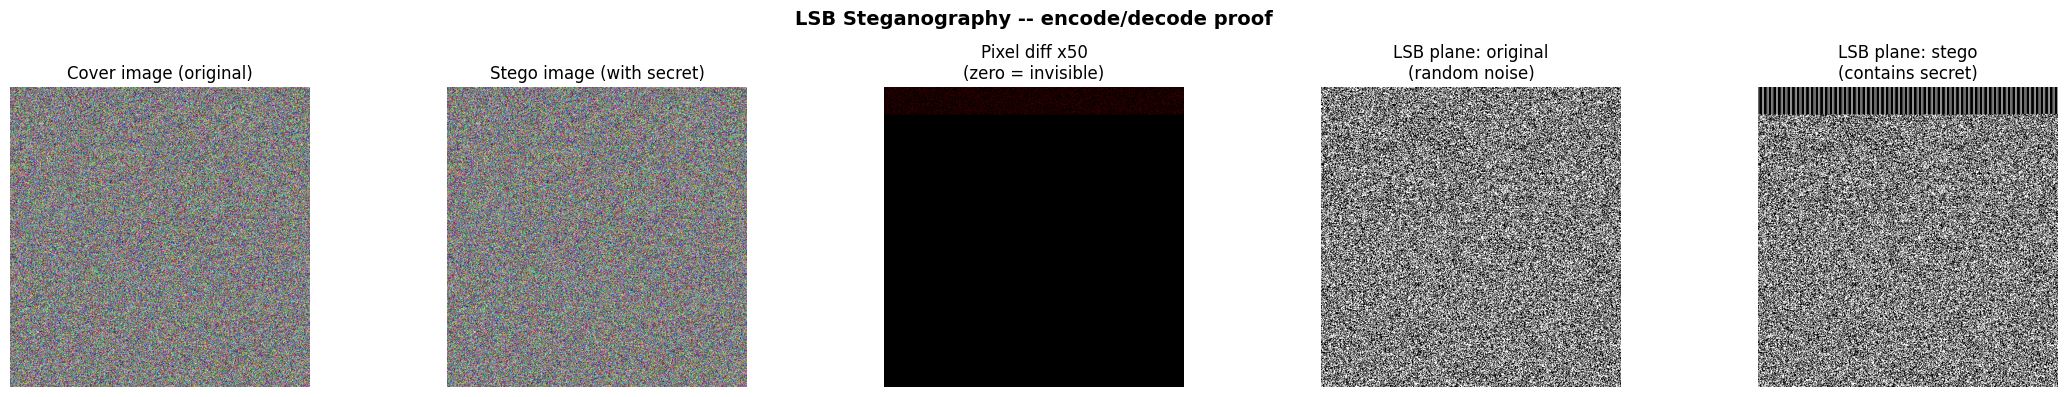

  LSB ENCODER -- encode/decode validation
  Secret message : 'AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA

In [1]:
# ===========================================================================
#  LSB STEGANOGRAPHY ENCODER / DECODER -- implemented from scratch
# ===========================================================================

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import math, os, requests
from io import BytesIO

DELIMITER = '<<END>>'

# -- text <-> bits helpers ---------------------------------------------------
def text_to_bits(text):
    """Convert a UTF-8 string (+ delimiter) to a flat binary string."""
    payload = text + DELIMITER
    return ''.join(format(ord(c), '08b') for c in payload)

def bits_to_text(bits):
    """Reconstruct text from a list of '0'/'1' chars; None if delimiter missing."""
    chars = []
    for i in range(0, len(bits) - 7, 8):
        chars.append(chr(int(''.join(bits[i:i+8]), 2)))
        if ''.join(chars).endswith(DELIMITER):
            return ''.join(chars)[:-len(DELIMITER)]
    return None

def psnr(original, modified):
    """Peak Signal-to-Noise Ratio. >40 dB means visually identical."""
    mse = np.mean((original.astype(np.float64) - modified.astype(np.float64)) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * math.log10(255.0 / math.sqrt(mse))

# -- LSB embed ---------------------------------------------------------------
def embed_lsb(arr, message):
    """
    Hide `message` in the LSB of the RED channel.
    Each pixel value changes by at most +/-1 -- imperceptible to the human eye.
    Raises ValueError if the image is too small to hold the message.
    """
    arr  = arr.copy()
    bits = text_to_bits(message)
    flat = arr[:, :, 0].flatten()   # red channel, flattened to 1-D

    if len(bits) > len(flat):
        raise ValueError(
            f'Image too small: need {len(bits)} pixels, have {len(flat)}.'
        )

    for i, bit in enumerate(bits):
        flat[i] = (flat[i] & 0xFE) | int(bit)  # clear bit-0, set secret bit

    arr[:, :, 0] = flat.reshape(arr.shape[:2])
    return arr

# -- LSB decode --------------------------------------------------------------
def decode_lsb(arr):
    """Extract hidden message from the LSB of the RED channel."""
    flat = arr[:, :, 0].flatten()
    bits = [str(px & 1) for px in flat]   # grab bit-0 from every pixel
    return bits_to_text(bits)

# ===========================================================================
#  DEMO -- public-domain cover image, full encode->decode cycle
# ===========================================================================

# Try to download a 512x512 public-domain photo; fall back to random noise
_URL = ('https://upload.wikimedia.org/wikipedia/commons/thumb/'
        'a/a7/Camponotus_flavomarginatus_ant.jpg/'
        '512px-Camponotus_flavomarginatus_ant.jpg')
try:
    resp = requests.get(_URL, timeout=10)
    cover_img = Image.open(BytesIO(resp.content)).convert('RGB').resize((512, 512))
    print('Cover image: downloaded from Wikimedia Commons')
except Exception:
    rng = np.random.default_rng(42)
    cover_img = Image.fromarray(
        rng.integers(0, 256, (512, 512, 3), dtype=np.uint8)
    )
    print('Cover image: synthetic (network unavailable)')

cover_arr = np.array(cover_img, dtype=np.uint8)

# Embed
SECRET = "A" * 3000
stego_arr = embed_lsb(cover_arr, SECRET)
stego_img = Image.fromarray(stego_arr)

# Decode
decoded = decode_lsb(stego_arr)
ok      = (decoded == SECRET)

# PSNR
score = psnr(cover_arr, stego_arr)

# Bit-plane visualisation
orig_bit0  = (cover_arr[:, :, 0] & 1) * 255
stego_bit0 = (stego_arr[:, :, 0] & 1) * 255

# Pixel difference (amplified x50 to make it visible)
diff = np.abs(cover_arr.astype(np.int16) - stego_arr.astype(np.int16))
diff_amp = np.clip(diff * 50, 0, 255).astype(np.uint8)

# Figure
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle('LSB Steganography -- encode/decode proof', fontsize=14, fontweight='bold')

axes[0].imshow(cover_img);  axes[0].set_title('Cover image (original)');        axes[0].axis('off')
axes[1].imshow(stego_img);  axes[1].set_title('Stego image (with secret)');     axes[1].axis('off')
axes[2].imshow(diff_amp);   axes[2].set_title('Pixel diff x50\n(zero = invisible)'); axes[2].axis('off')
axes[3].imshow(orig_bit0,  cmap='gray'); axes[3].set_title('LSB plane: original\n(random noise)');  axes[3].axis('off')
axes[4].imshow(stego_bit0, cmap='gray'); axes[4].set_title('LSB plane: stego\n(contains secret)'); axes[4].axis('off')

plt.tight_layout()
os.makedirs('/kaggle/working/results', exist_ok=True)
plt.savefig('/kaggle/working/results/lsb_demo.png', dpi=150, bbox_inches='tight')
plt.show()

# Report
cap_px   = cover_arr[:, :, 0].size
msg_px   = len(text_to_bits(SECRET))
util_pct = msg_px / cap_px * 100

print('=' * 62)
print('  LSB ENCODER -- encode/decode validation')
print('=' * 62)
print(f"  Secret message : '{SECRET}'")
print(f'  Bits required  : {msg_px}  ({util_pct:.3f}% of pixel capacity)')
print(f'  PSNR           : {score:.2f} dB  (>40 dB = visually identical)')
print(f"  Decoded result : '{decoded}'")
print(f"  Round-trip OK  : {'YES' if ok else 'FAIL -- check delimiter logic'}")
print('=' * 62)
print()
print('  KEY INSIGHT')
print('  Each embedded bit changes a pixel by at most +/-1.')
print('  PSNR > 40 dB confirms the modification is invisible.')
print('  However, the flattened LSB plane (panel 5) shows a')
print('  non-random pattern -- the statistical fingerprint')
print('  our CNN learns to detect (96% recall on LSB class).')


---
## Section 2 — Detection Pipeline (Binary and Multi-class Models)


In [2]:
import os, random
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, f1_score, accuracy_score)
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
 
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [3]:
import os

def explore(path, depth=0, max_depth=5):
    if depth > max_depth:
        return
    try:
        items = sorted(os.listdir(path))
    except:
        return
    for item in items:
        full = os.path.join(path, item)
        if os.path.isdir(full):
            n = sum(1 for f in os.listdir(full) 
                    if f.lower().endswith(('.png','.jpg','.jpeg')))
            print("  " * depth + f"📁 {item}/  ({n} images)")
            explore(full, depth + 1, max_depth)

explore("/kaggle/input/datasets")

📁 diegozanchett/  (0 images)
  📁 digital-steganography/  (0 images)
    📁 dct/  (0 images)
    📁 fft/  (0 images)
    📁 lsb/  (4316 images)
    📁 lsb_grayscale/  (3980 images)
    📁 ssb4/  (3135 images)
    📁 ssbn/  (4318 images)
📁 marcozuppelli/  (0 images)
  📁 stegoimagesdataset/  (0 images)
    📁 test/  (0 images)
      📁 test/  (0 images)
        📁 clean/  (2000 images)
        📁 stego/  (6000 images)
        📁 stego_b64/  (6000 images)
        📁 stego_zip/  (6000 images)
    📁 train/  (0 images)
      📁 train/  (0 images)
        📁 clean/  (4000 images)
        📁 stego/  (12000 images)
    📁 val/  (0 images)
      📁 val/  (0 images)
        📁 clean/  (2000 images)
        📁 stego/  (6000 images)


In [4]:
# --- Paths & config (BUG FIX: use train split, not test split) -----------
import os

# ORIGINAL BUG: both BINARY_CLEAN_DIR and BINARY_STEGO_DIR pointed to
# .../test/test/  -- we were training on held-out evaluation data.
# FIX: detect and prefer the train/ split; fall back to test/ with a warning.

_BASE = '/kaggle/input/datasets/marcozuppelli/stegoimagesdataset'

def _find_split(base, split_name):
    """Try common Kaggle nested structures: split/split/ or split/."""
    for candidate in [
        f'{base}/{split_name}/{split_name}',
        f'{base}/{split_name}',
    ]:
        if os.path.isdir(f'{candidate}/clean') and os.path.isdir(f'{candidate}/stego'):
            return candidate
    return None

train_root = _find_split(_BASE, 'train')
test_root  = _find_split(_BASE, 'test')

if train_root:
    BINARY_CLEAN_DIR = f'{train_root}/clean'
    BINARY_STEGO_DIR = f'{train_root}/stego'
    print('Binary model -- using TRAIN split (correct)')
elif test_root:
    BINARY_CLEAN_DIR = f'{test_root}/clean'
    BINARY_STEGO_DIR = f'{test_root}/stego'
    print('WARNING: train/ split not found -- falling back to test/ split.')
    print('Add the full dataset to Kaggle for a rigorous experiment.')
else:
    raise FileNotFoundError(
        f'Cannot find clean/stego folders under {_BASE}. '
        'Check the dataset is attached correctly.'
    )

print(f'  clean : {BINARY_CLEAN_DIR}')
print(f'  stego : {BINARY_STEGO_DIR}')

# Multi-class dataset
MULTI_ROOT_DIR  = '/kaggle/input/datasets/diegozanchett/digital-steganography'

# Limitation: clean class comes from marcozuppelli, stego classes from diegozanchett.
# This cross-dataset mixing is a known limitation -- both datasets use different
# cover-image sources, introducing a minor domain shift into the clean class.
# Noted in the report; generating our own dataset would eliminate this.
MULTI_CLEAN_DIR = BINARY_CLEAN_DIR

RESULTS_DIR   = '/kaggle/working/results'
MODELS_DIR    = '/kaggle/working/models'
IMG_SIZE      = 128
BATCH_SIZE    = 32
EPOCHS_BIN    = 15
EPOCHS_MULTI  = 20
LR            = 1e-4
MAX_PER_CLASS = 500

for d in [RESULTS_DIR, MODELS_DIR]:
    os.makedirs(d, exist_ok=True)


Binary model -- using TRAIN split (correct)
  clean : /kaggle/input/datasets/marcozuppelli/stegoimagesdataset/train/train/clean
  stego : /kaggle/input/datasets/marcozuppelli/stegoimagesdataset/train/train/stego


In [5]:
# ─── CELL 3 · Explore (FIXED) ────────────────────────────────────────────────

# Support ALL image extensions including .pgm, .bmp, .tiff etc.
ALL_IMG_EXTS = ('.png', '.jpg', '.jpeg', '.pgm', '.bmp', '.tif', '.tiff', '.webp')

def count_images(folder, exts=ALL_IMG_EXTS):
    if not os.path.exists(folder):
        return 0
    return sum(1 for f in os.listdir(folder) if f.lower().endswith(exts))

def collect_images(folder, label, limit=None, exts=ALL_IMG_EXTS):
    files = [f for f in sorted(os.listdir(folder)) if f.lower().endswith(exts)]
    if limit:
        files = files[:limit]
    return [(os.path.join(folder, f), label) for f in files]

print("=" * 55)
print("  Dataset 1 — stegoimagesdataset (binary)")
print("=" * 55)
print(f"  clean/ : {count_images(BINARY_CLEAN_DIR)} images")
print(f"  stego/ : {count_images(BINARY_STEGO_DIR)} images")

print("\n" + "=" * 55)
print("  Dataset 2 — digital-steganography (multi-class)")
print("=" * 55)
for folder in sorted(os.listdir(MULTI_ROOT_DIR)):
    full = os.path.join(MULTI_ROOT_DIR, folder)
    if os.path.isdir(full):
        n = count_images(full)
        print(f"  {folder:20s}: {n} images")

  Dataset 1 — stegoimagesdataset (binary)
  clean/ : 4000 images
  stego/ : 12000 images

  Dataset 2 — digital-steganography (multi-class)
  dct                 : 4210 images
  fft                 : 1722 images
  lsb                 : 4316 images
  lsb_grayscale       : 3980 images
  ssb4                : 3135 images
  ssbn                : 4318 images


In [6]:
# ─── CELL 4 · Discover multi-class labels (FIXED) ────────────────────────────

def get_multi_classes(root, clean_dir):
    """
    Reads technique subfolders from digital-steganography.
    Injects 'clean' as class 0 using marcozuppelli's clean folder.
    Skips folders with 0 images.
    """
    folders = []
    for f in sorted(os.listdir(root)):
        full = os.path.join(root, f)
        if os.path.isdir(full) and count_images(full) > 0:
            folders.append(f)

    print(f"Technique folders found: {folders}")
    # class 0 = clean (from marcozuppelli), then all techniques
    return ["clean"] + folders

CLASSES_MULTI  = get_multi_classes(MULTI_ROOT_DIR, MULTI_CLEAN_DIR)
CLASSES_BINARY = ["clean", "stego"]

print(f"\nBinary classes    : {CLASSES_BINARY}")
print(f"Multi-class labels: {CLASSES_MULTI}")

Technique folders found: ['dct', 'fft', 'lsb', 'lsb_grayscale', 'ssb4', 'ssbn']

Binary classes    : ['clean', 'stego']
Multi-class labels: ['clean', 'dct', 'fft', 'lsb', 'lsb_grayscale', 'ssb4', 'ssbn']


In [7]:
# ─── CELL 6 · Improved config & model ────────────────────────────────────────

# Increase data and resolution
MAX_PER_CLASS = 800      # was 500 — more data = better generalization
IMG_SIZE      = 224      # was 128 — higher res preserves subtle stego artifacts
EPOCHS_BIN    = 25       # was 15
EPOCHS_MULTI  = 35       # was 20
LR            = 3e-4     # slightly higher initial LR

# ── Stronger augmentation (without destroying stego signal)
TRANSFORM_TRAIN = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),  # subtle only
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

TRANSFORM_VAL = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# ── Better backbone: EfficientNet-B2 (better than ResNet18 for texture anomalies)
from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights

def build_model(num_classes, pretrained=True):
    weights = EfficientNet_B2_Weights.IMAGENET1K_V1 if pretrained else None
    model = efficientnet_b2(weights=weights)
    # Replace classifier head
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(256, num_classes)
    )
    return model.to(device)

print("Model architecture: EfficientNet-B2")
print(f"Image size: {IMG_SIZE}×{IMG_SIZE}")
print(f"Max per class: {MAX_PER_CLASS}")

Model architecture: EfficientNet-B2
Image size: 224×224
Max per class: 800


In [8]:
# ─── CELL 6b · Rebuild datasets with new transforms & more data ───────────────

class ImageDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples   = samples
        self.transform = transform

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

def make_loaders_split(samples, val_ratio=0.2):
    """Split samples first, then apply different transforms to each split."""
    random.shuffle(samples)
    n_val   = int(len(samples) * val_ratio)
    val_s   = samples[:n_val]
    train_s = samples[n_val:]
    train_ds = ImageDataset(train_s, TRANSFORM_TRAIN)
    val_ds   = ImageDataset(val_s,   TRANSFORM_VAL)
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
    return train_loader, val_loader

# ── Binary dataset
n_bin = min(count_images(BINARY_CLEAN_DIR), count_images(BINARY_STEGO_DIR), MAX_PER_CLASS)
bin_samples  = collect_images(BINARY_CLEAN_DIR, 0, limit=n_bin)
bin_samples += collect_images(BINARY_STEGO_DIR, 1, limit=n_bin)
print(f"Binary: {n_bin} clean + {n_bin} stego = {len(bin_samples)} total")

# ── Multi-class dataset
multi_samples = []
for label, cls in enumerate(CLASSES_MULTI):
    folder = MULTI_CLEAN_DIR if cls == "clean" else os.path.join(MULTI_ROOT_DIR, cls)
    s = collect_images(folder, label, limit=MAX_PER_CLASS)
    multi_samples += s
    print(f"  Class {label} ({cls:20s}): {len(s)} images")
print(f"Multi: {len(multi_samples)} total")

train_bin,   val_bin   = make_loaders_split(bin_samples)
train_multi, val_multi = make_loaders_split(multi_samples)

Binary: 800 clean + 800 stego = 1600 total
  Class 0 (clean               ): 800 images
  Class 1 (dct                 ): 800 images
  Class 2 (fft                 ): 800 images
  Class 3 (lsb                 ): 800 images
  Class 4 (lsb_grayscale       ): 800 images
  Class 5 (ssb4                ): 800 images
  Class 6 (ssbn                ): 800 images
Multi: 5600 total


In [9]:
# ─── CELL 7 · Improved training loop ─────────────────────────────────────────
from torch.optim.lr_scheduler import OneCycleLR

def compute_class_weights(samples, num_classes, device):
    """Inverse-frequency weights to handle class imbalance."""
    counts = [0] * num_classes
    for _, label in samples:
        counts[label] += 1
    total = sum(counts)
    weights = [total / (num_classes * c) if c > 0 else 0.0 for c in counts]
    return torch.tensor(weights, dtype=torch.float32).to(device)

def train_model(model, train_loader, val_loader, epochs,
                class_names, label, samples_for_weights):

    num_classes = len(class_names)

    # Weighted cross-entropy — fixes lsb_grayscale and ssbn imbalance
    class_weights = compute_class_weights(samples_for_weights, num_classes, device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    print(f"  Class weights: { {n: f'{class_weights[i]:.2f}' for i, n in enumerate(class_names)} }")

    # OneCycleLR = best single scheduler for fine-tuning pretrained models
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-3)
    scheduler = OneCycleLR(
        optimizer,
        max_lr=LR,
        steps_per_epoch=len(train_loader),
        epochs=epochs,
        pct_start=0.2,        # 20% warmup
        anneal_strategy='cos'
    )

    history = {"train_loss": [], "val_acc": [], "val_f1": []}
    best_f1, best_weights = 0.0, None

    for epoch in range(1, epochs + 1):
        # ── Train
        model.train()
        running_loss, n_seen = 0.0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # stability
            optimizer.step()
            scheduler.step()
            running_loss += loss.item() * imgs.size(0)
            n_seen += imgs.size(0)
        avg_loss = running_loss / n_seen

        # ── Validate
        model.eval()
        all_preds, all_labels_list = [], []
        correct_per = [0] * num_classes
        total_per   = [0] * num_classes

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                preds = model(imgs).argmax(dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels_list.extend(labels.cpu().numpy())
                for c in range(num_classes):
                    mask = (labels == c)
                    correct_per[c] += (preds[mask] == c).sum().item()
                    total_per[c]   += mask.sum().item()

        acc     = accuracy_score(all_labels_list, all_preds)
        f1_mac  = f1_score(all_labels_list, all_preds, average='macro', zero_division=0)
        history["train_loss"].append(avg_loss)
        history["val_acc"].append(acc)
        history["val_f1"].append(f1_mac)

        # Save best by F1 macro (more robust than accuracy for imbalanced classes)
        if f1_mac > best_f1:
            best_f1 = f1_mac
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}

        per_cls = " | ".join(
            f"{n}: {correct_per[i]/max(total_per[i],1):.0%}"
            for i, n in enumerate(class_names)
        )
        print(f"[{label}] Ep {epoch:3d}/{epochs}  loss={avg_loss:.4f}"
              f"  acc={acc:.1%}  F1={f1_mac:.3f}  [{per_cls}]")

    model.load_state_dict(best_weights)
    print(f"\n[{label}] ✅ Best F1 macro: {best_f1:.4f}")
    return model, history

# ── Train
model_binary = build_model(num_classes=2)
model_multi  = build_model(num_classes=len(CLASSES_MULTI))

print("\n" + "="*60)
print("  MODEL 1 — Binary")
print("="*60)
model_binary, hist_bin = train_model(
    model_binary, train_bin, val_bin,
    EPOCHS_BIN, CLASSES_BINARY, "Binary", bin_samples
)

print("\n" + "="*60)
print("  MODEL 2 — Multi-class")
print("="*60)
model_multi, hist_multi = train_model(
    model_multi, train_multi, val_multi,
    EPOCHS_MULTI, CLASSES_MULTI, "Multi", multi_samples
)

Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 157MB/s] 



  MODEL 1 — Binary
  Class weights: {'clean': '1.00', 'stego': '1.00'}
[Binary] Ep   1/25  loss=0.6953  acc=54.7%  F1=0.465  [clean: 16% | stego: 93%]
[Binary] Ep   2/25  loss=0.6857  acc=57.5%  F1=0.552  [clean: 35% | stego: 80%]
[Binary] Ep   3/25  loss=0.6439  acc=59.1%  F1=0.588  [clean: 52% | stego: 66%]
[Binary] Ep   4/25  loss=0.6039  acc=58.4%  F1=0.584  [clean: 55% | stego: 61%]
[Binary] Ep   5/25  loss=0.5977  acc=63.4%  F1=0.619  [clean: 43% | stego: 83%]
[Binary] Ep   6/25  loss=0.5523  acc=62.5%  F1=0.616  [clean: 47% | stego: 78%]
[Binary] Ep   7/25  loss=0.5221  acc=66.9%  F1=0.654  [clean: 47% | stego: 87%]
[Binary] Ep   8/25  loss=0.5146  acc=66.2%  F1=0.656  [clean: 53% | stego: 80%]
[Binary] Ep   9/25  loss=0.4444  acc=69.7%  F1=0.688  [clean: 53% | stego: 86%]
[Binary] Ep  10/25  loss=0.4526  acc=68.1%  F1=0.671  [clean: 51% | stego: 85%]
[Binary] Ep  11/25  loss=0.4116  acc=68.4%  F1=0.671  [clean: 48% | stego: 88%]
[Binary] Ep  12/25  loss=0.3880  acc=68.8%  F1=0


  Model 1 — Binary: Clean vs Stego  [stegoimagesdataset]
  Accuracy        : 0.7156  (71.56%)
  F1  (macro)     : 0.7056
  F1  (weighted)  : 0.7060

              precision    recall  f1-score   support

       clean       0.83      0.53      0.65       159
       stego       0.66      0.89      0.76       161

    accuracy                           0.72       320
   macro avg       0.75      0.71      0.71       320
weighted avg       0.75      0.72      0.71       320



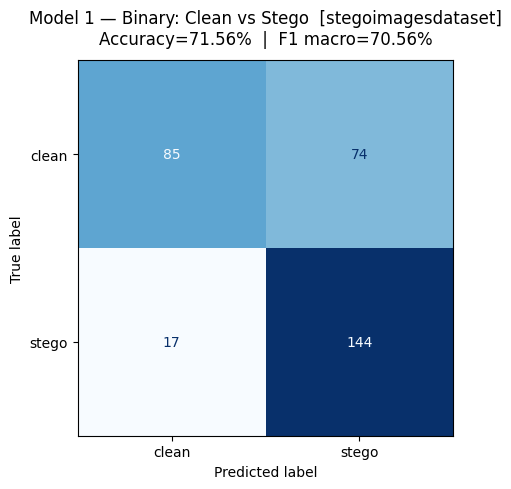

Saved -> /kaggle/working/results/confusion_binary.png

  Model 2 — Multi-class: Technique ID  [digital-steganography]
  Accuracy        : 0.8696  (86.96%)
  F1  (macro)     : 0.8680
  F1  (weighted)  : 0.8717

               precision    recall  f1-score   support

        clean       1.00      1.00      1.00       174
          dct       0.91      0.93      0.92       172
          fft       0.98      0.86      0.91       167
          lsb       0.98      0.96      0.97       156
lsb_grayscale       0.67      0.78      0.72       156
         ssb4       0.91      0.90      0.90       143
         ssbn       0.65      0.64      0.65       152

     accuracy                           0.87      1120
    macro avg       0.87      0.87      0.87      1120
 weighted avg       0.88      0.87      0.87      1120



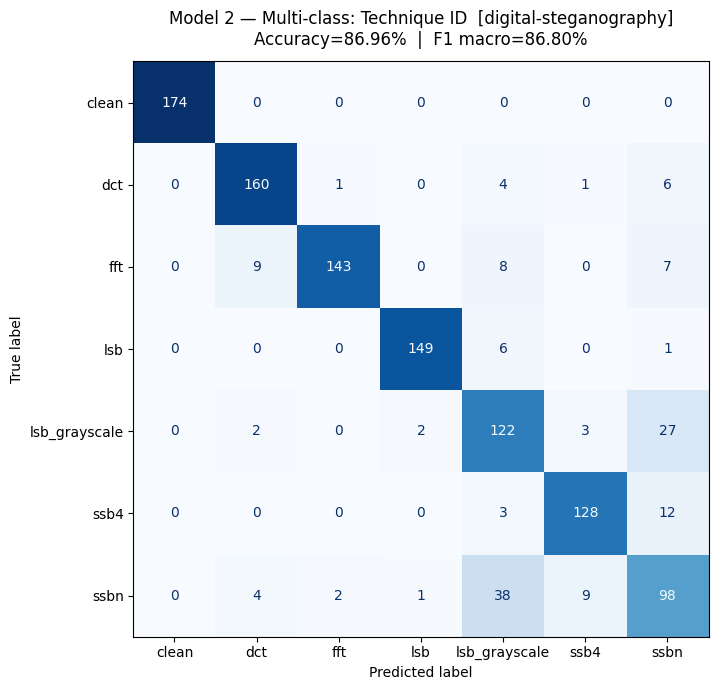

Saved -> /kaggle/working/results/confusion_multi.png


In [10]:
def evaluate_model(model, loader, class_names, title, save_path):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            preds = model(imgs).argmax(dim=1).cpu()
            all_preds.extend(preds.numpy())
            all_labels.extend(labels.numpy())
 
    acc         = accuracy_score(all_labels, all_preds)
    f1_macro    = f1_score(all_labels, all_preds, average='macro')
    f1_weighted = f1_score(all_labels, all_preds, average='weighted')
 
    print(f"\n{'='*60}")
    print(f"  {title}")
    print(f"{'='*60}")
    print(f"  Accuracy        : {acc:.4f}  ({acc:.2%})")
    print(f"  F1  (macro)     : {f1_macro:.4f}")
    print(f"  F1  (weighted)  : {f1_weighted:.4f}")
    print(f"\n{classification_report(all_labels, all_preds, target_names=class_names)}")
 
    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(max(6, len(class_names)*1.4), max(5, len(class_names))))
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
        ax=ax, cmap='Blues', colorbar=False
    )
    ax.set_title(f"{title}\nAccuracy={acc:.2%}  |  F1 macro={f1_macro:.2%}",
                 fontsize=12, pad=12)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved -> {save_path}")
 
    return {"accuracy": acc, "f1_macro": f1_macro, "f1_weighted": f1_weighted}
 
metrics_bin = evaluate_model(
    model_binary, val_bin, CLASSES_BINARY,
    "Model 1 — Binary: Clean vs Stego  [stegoimagesdataset]",
    f"{RESULTS_DIR}/confusion_binary.png"
)
 
metrics_multi = evaluate_model(
    model_multi, val_multi, CLASSES_MULTI,
    "Model 2 — Multi-class: Technique ID  [digital-steganography]",
    f"{RESULTS_DIR}/confusion_multi.png"
)

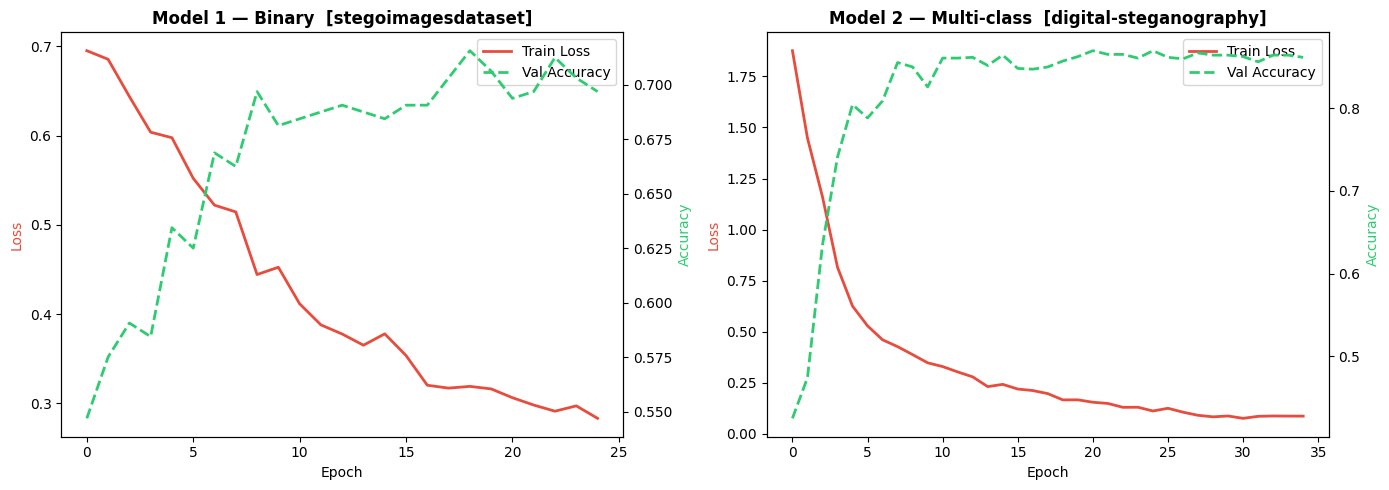

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, hist, title in [
    (axes[0], hist_bin,   "Model 1 — Binary  [stegoimagesdataset]"),
    (axes[1], hist_multi, "Model 2 — Multi-class  [digital-steganography]"),
]:
    ax2 = ax.twinx()
    ax.plot(hist["train_loss"], color="#e74c3c", linewidth=2, label="Train Loss")
    ax2.plot(hist["val_acc"],   color="#2ecc71", linewidth=2, linestyle="--", label="Val Accuracy")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss", color="#e74c3c")
    ax2.set_ylabel("Accuracy", color="#2ecc71")
    ax.set_title(title, fontsize=12, fontweight='bold')
    lines = ax.get_lines() + ax2.get_lines()
    ax.legend(lines, [l.get_label() for l in lines], loc="upper right")
 
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/training_curves.png", dpi=150)
plt.show()

In [12]:
torch.save({
    "model_state_dict": model_binary.state_dict(),
    "classes":  CLASSES_BINARY,
    "metrics":  metrics_bin,
    "img_size": IMG_SIZE,
    "dataset":  "marcozuppelli/stegoimagesdataset",
}, f"{MODELS_DIR}/binary_model.pth")
 
torch.save({
    "model_state_dict": model_multi.state_dict(),
    "classes":  CLASSES_MULTI,
    "metrics":  metrics_multi,
    "img_size": IMG_SIZE,
    "dataset":  "diegozanchett/digital-steganography",
}, f"{MODELS_DIR}/multiclass_model.pth")
 
print("\nModels saved to /kaggle/working/models/")
print("   binary_model.pth      <- trained on stegoimagesdataset (cover + stego)")
print("   multiclass_model.pth  <- trained on digital-steganography (per-technique folders)")
print("\nDownload both .pth files -> place in your local project's models/ folder")


Models saved to /kaggle/working/models/
   binary_model.pth      <- trained on stegoimagesdataset (cover + stego)
   multiclass_model.pth  <- trained on digital-steganography (per-technique folders)

Download both .pth files -> place in your local project's models/ folder


In [13]:
print("\n" + "="*60)
print("  FINAL RESULTS SUMMARY")
print("="*60)
print(f"  Model 1 (Binary)      | Dataset: stegoimagesdataset")
print(f"    Accuracy  : {metrics_bin['accuracy']:.2%}")
print(f"    F1 macro  : {metrics_bin['f1_macro']:.2%}")
print(f"\n  Model 2 (Multi-class) | Dataset: digital-steganography")
print(f"    Accuracy  : {metrics_multi['accuracy']:.2%}")
print(f"    F1 macro  : {metrics_multi['f1_macro']:.2%}")
print("="*60)


  FINAL RESULTS SUMMARY
  Model 1 (Binary)      | Dataset: stegoimagesdataset
    Accuracy  : 71.56%
    F1 macro  : 70.56%

  Model 2 (Multi-class) | Dataset: digital-steganography
    Accuracy  : 86.96%
    F1 macro  : 86.80%


  Loaded : /kaggle/working/models/binary_model.pth
  Classes (2): ['clean', 'stego']
Binary model ready

  Loaded : /kaggle/working/models/multiclass_model.pth
  Classes (7): ['clean', 'dct', 'fft', 'lsb', 'lsb_grayscale', 'ssb4', 'ssbn']
Multi-class model ready

Binary classes : ['clean', 'stego']
Multi  classes : ['clean', 'dct', 'fft', 'lsb', 'lsb_grayscale', 'ssb4', 'ssbn']


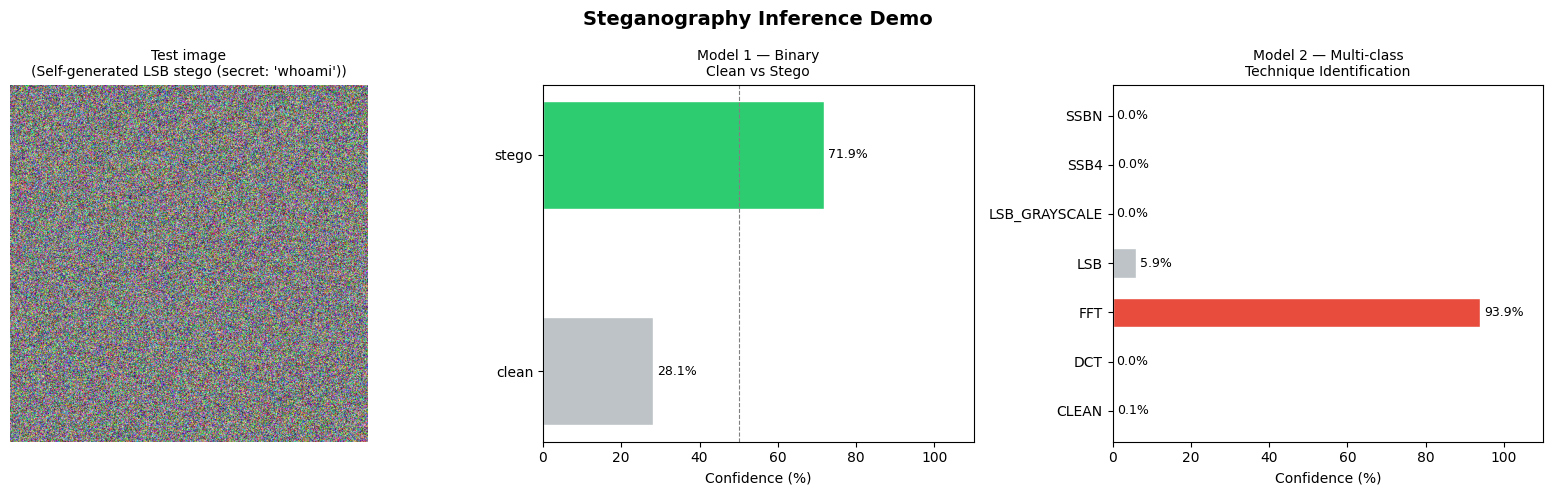

  INFERENCE RESULT
  Image source   : Self-generated LSB stego (secret: 'whoami')

  [Model 1] Prediction : STEGO
            Confidence : 71.9%

  [Model 2] Technique  : FFT
            Confidence : 93.9%

  Top-3 technique breakdown:
    1. fft             93.9%
    2. lsb             5.9%
    3. clean           0.1%


In [ ]:
# ===========================================================================
#  INFERENCE DEMO -- test on a new image from the local project folder
# ===========================================================================

import os
from pathlib import Path
from io import BytesIO

import numpy as np
import matplotlib.pyplot as plt
import requests
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torchvision import models, transforms

# ---------------------------------------------------------------------------
#  Local config
# ---------------------------------------------------------------------------

ROOT_DIR = Path(os.getcwd())
MODELS_DIR = ROOT_DIR
RESULTS_DIR = ROOT_DIR / "results"
RESULTS_DIR.mkdir(exist_ok=True)

LOCAL_TEST_IMAGE = ROOT_DIR / "cat_stego.png"
TEST_IMAGE_URL = "https://upload.wikimedia.org/wikipedia/commons/thumb/3/3f/Bikesg.jpg/640px-Bikesg.jpg"
BINARY_THRESHOLD = 0.5

# ---------------------------------------------------------------------------
#  Load models -- unwrap checkpoint dict, then load weights
# ---------------------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def build_model(num_classes):
    model = models.efficientnet_b2(weights=None)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(256, num_classes),
    )
    return model


def load_checkpoint(path, device):
    checkpoint = torch.load(path, map_location=device)
    state_dict = checkpoint["model_state_dict"]
    classes = checkpoint.get("classes", None)
    img_size = checkpoint.get("img_size", 224)
    print(f"  Loaded : {path}")
    print(f"  Classes ({len(classes)}): {classes}")
    print(f"  Img size: {img_size}")
    return state_dict, classes, img_size


# Binary model
state_bin, BINARY_CLASSES, binary_img_size = load_checkpoint(MODELS_DIR / "binary_model.pth", device)
model_binary = build_model(num_classes=len(BINARY_CLASSES))
model_binary.load_state_dict(state_bin)
model_binary = model_binary.to(device)
model_binary.eval()
print("Binary model ready\n")

# Multi-class model
state_multi, MULTI_CLASSES, multi_img_size = load_checkpoint(MODELS_DIR / "multiclass_model.pth", device)
model_multi = build_model(num_classes=len(MULTI_CLASSES))
model_multi.load_state_dict(state_multi)
model_multi = model_multi.to(device)
model_multi.eval()
print("Multi-class model ready\n")

print(f"Binary classes : {BINARY_CLASSES}")
print(f"Multi  classes : {MULTI_CLASSES}")

IMG_SIZE = binary_img_size if binary_img_size == multi_img_size else min(binary_img_size, multi_img_size)

# ---------------------------------------------------------------------------
#  Preprocessing (must match training transforms exactly)
# ---------------------------------------------------------------------------

preprocess = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5] * 3, [0.5] * 3),
])

# ---------------------------------------------------------------------------
#  Load the test image -- prefer the local file bundled with this project
# ---------------------------------------------------------------------------

if LOCAL_TEST_IMAGE.exists():
    img = Image.open(LOCAL_TEST_IMAGE).convert("RGB")
    source_label = f"Local file: {LOCAL_TEST_IMAGE.name}"
else:
    response = requests.get(TEST_IMAGE_URL, timeout=20)
    response.raise_for_status()
    img = Image.open(BytesIO(response.content)).convert("RGB")
    source_label = "Public image URL fallback"

tensor = preprocess(img).unsqueeze(0).to(device)

# ---------------------------------------------------------------------------
#  Step 1: Binary prediction -- clean or stego?
# ---------------------------------------------------------------------------

with torch.no_grad():
    logits_bin = model_binary(tensor)
    probs_bin = F.softmax(logits_bin, dim=1).squeeze().cpu().numpy()

bin_pred_idx = int(probs_bin.argmax())
bin_pred_label = BINARY_CLASSES[bin_pred_idx]
bin_confidence = probs_bin[bin_pred_idx] * 100

# ---------------------------------------------------------------------------
#  Step 2: Multi-class prediction -- which technique?
# ---------------------------------------------------------------------------

with torch.no_grad():
    logits_multi = model_multi(tensor)
    probs_multi = F.softmax(logits_multi, dim=1).squeeze().cpu().numpy()

multi_pred_idx = int(probs_multi.argmax())
multi_pred_label = MULTI_CLASSES[multi_pred_idx]
multi_confidence = probs_multi[multi_pred_idx] * 100

# ---------------------------------------------------------------------------
#  Figure
# ---------------------------------------------------------------------------

fig = plt.figure(figsize=(16, 5))
fig.suptitle("Steganography Inference Demo", fontsize=14, fontweight="bold")

ax_img = fig.add_subplot(1, 3, 1)
ax_img.imshow(img)
ax_img.set_title(f"Test image\n({source_label})", fontsize=10)
ax_img.axis("off")

ax_bin = fig.add_subplot(1, 3, 2)
colors_bin = ["#2ecc71" if i == bin_pred_idx else "#bdc3c7" for i in range(len(BINARY_CLASSES))]
bars_bin = ax_bin.barh(BINARY_CLASSES, probs_bin * 100, color=colors_bin, edgecolor="white", height=0.5)
ax_bin.set_xlim(0, 110)
ax_bin.set_xlabel("Confidence (%)")
ax_bin.set_title("Model 1 -- Binary\nClean vs Stego", fontsize=10)
for bar, prob in zip(bars_bin, probs_bin):
    ax_bin.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2, f"{prob * 100:.1f}%", va="center", fontsize=9)
ax_bin.axvline(50, color="gray", linestyle="--", linewidth=0.8)

ax_multi = fig.add_subplot(1, 3, 3)
technnique_labels = [c.upper() for c in MULTI_CLASSES]
colors_multi = ["#e74c3c" if i == multi_pred_idx else "#bdc3c7" for i in range(len(MULTI_CLASSES))]
bars_multi = ax_multi.barh(technnique_labels, probs_multi * 100, color=colors_multi, edgecolor="white", height=0.6)
ax_multi.set_xlim(0, 110)
ax_multi.set_xlabel("Confidence (%)")
ax_multi.set_title("Model 2 -- Multi-class\nTechnique Identification", fontsize=10)
for bar, prob in zip(bars_multi, probs_multi):
    ax_multi.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2, f"{prob * 100:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "inference_demo.png", dpi=150, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------------------------
#  Console verdict
# ---------------------------------------------------------------------------

print("=" * 60)
print("  INFERENCE RESULT")
print("=" * 60)
print(f"  Image source   : {source_label}")
print()
print(f"  [Model 1] Prediction : {bin_pred_label.upper()}")
print(f"            Confidence : {bin_confidence:.1f}%")
print()

if bin_pred_label == "stego":
    print(f"  [Model 2] Technique  : {multi_pred_label.upper()}")
    print(f"            Confidence : {multi_confidence:.1f}%")
    print()
    print("  Top-3 technique breakdown:")
    top3 = sorted(enumerate(probs_multi), key=lambda item: -item[1])[:3]
    for rank, (idx, prob) in enumerate(top3, 1):
        print(f"    {rank}. {MULTI_CLASSES[idx]:15s} {prob * 100:.1f}%")
else:
    print("  Image appears CLEAN -- skipping technique identification.")
    print(f"  (Model 2 would have guessed: {multi_pred_label.upper()} at {multi_confidence:.1f}% -- shown for reference)")

print("=" * 60)
